In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root, len(files), files[:5])

/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/README - README.pdf
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/README_csv - README.pdf
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00128-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00089-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00034-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00042-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00160-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/datasets/madhavmalhotra/unb-cic-iot-dataset/wataiData/csv/CICIoT2023/part-00096-363d1ba3-8ab5-4f96-bc2

In [1]:
try:
    print(X_tr.shape, X_te.shape, type(light_model).__name__)
    print("State OK")
except NameError as e:
    print("State gayab:", e)

State gayab: name 'X_tr' is not defined


In [2]:
import pandas as pd, numpy as np, glob, os, joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, roc_auc_score, average_precision_score)
from xgboost import XGBClassifier

# 1) data
csvs = sorted(glob.glob('/kaggle/input/**/*.csv', recursive=True))
chosen = csvs[::8]
parts = [pd.read_csv(f).sample(frac=0.2, random_state=42) for f in chosen]
df = pd.concat(parts, ignore_index=True); del parts
df = df.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates().reset_index(drop=True)
df['y'] = (df['label'] != 'BenignTraffic').astype(int)
print(df.shape)                       # 1130477 x 48 aana chahiye

# 2) split
feature_cols = [c for c in df.columns if c not in ['label', 'y']]
X, y = df[feature_cols], df['y']
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
print(X_tr.shape, X_val.shape, X_te.shape)

# 3) helpers
def evaluate(name, model, Xe, ye):
    pred = model.predict(Xe); score = model.predict_proba(Xe)[:, 1]
    tn, fp, fn, tp = confusion_matrix(ye, pred).ravel()
    return dict(model=name, precision=precision_score(ye, pred), recall=recall_score(ye, pred),
                f1=f1_score(ye, pred), mcc=matthews_corrcoef(ye, pred), fpr=fp/(fp+tn),
                auroc=roc_auc_score(ye, score), auprc=average_precision_score(ye, score))

def family(l):
    if l == 'BenignTraffic': return 'Benign'
    if l.startswith('DDoS'): return 'DDoS'
    if l.startswith('DoS'): return 'DoS'
    if l.startswith('Mirai'): return 'Mirai'
    if l.startswith('Recon') or l == 'VulnerabilityScan': return 'Recon'
    if l in ('MITM-ArpSpoofing', 'DNS_Spoofing'): return 'Spoofing'
    if l == 'DictionaryBruteForce': return 'BruteForce'
    return 'Web'
fam = df['label'].map(family)

# 4) models
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
xgb_full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=42, scale_pos_weight=pos_w).fit(X_tr, y_tr)
imp = pd.Series(xgb_full.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
feats20 = imp.index[:20].tolist()
light_model = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                            n_jobs=2, random_state=42, scale_pos_weight=pos_w).fit(X_tr[feats20], y_tr)
print(imp.head(3))
print(evaluate('light_test', light_model, X_te[feats20], y_te))

(1130477, 48)
(791333, 46) (169572, 46) (169572, 46)
rst_count    0.854965
Number       0.033251
Weight       0.021033
dtype: float32
{'model': 'light_test', 'precision': 0.9999878132749995, 'recall': 0.9912778230799433, 'f1': 0.9956137690039676, 'mcc': np.float64(0.8536330708098095), 'fpr': np.float64(0.0004978839930296241), 'auroc': np.float64(0.9991347681116691), 'auprc': np.float64(0.9999787711284087)}


In [3]:
Xf = X_te[feats20]
pred = light_model.predict(Xf)
yv = y_te.values
labels_te = df.loc[X_te.index, 'label'].values

tp = np.where((yv == 1) & (pred == 1))[0]
fp = np.where((yv == 0) & (pred == 1))[0]
fn = np.where((yv == 1) & (pred == 0))[0]
print("TP:", len(tp), " FP:", len(fp), " FN:", len(fn))
print("\nFN attack types (missed by light model):")
print(pd.Series(labels_te[fn]).value_counts().to_string())
print("\nFP labels:", list(labels_te[fp]))
print("First TP label:", labels_te[tp[0]])

TP: 164111  FP: 2  FN: 1444

FN attack types (missed by light model):
MITM-ArpSpoofing           551
DNS_Spoofing               261
Recon-OSScan               254
Recon-HostDiscovery        145
Recon-PortScan             112
DictionaryBruteForce        48
SqlInjection                17
XSS                         13
BrowserHijacking            13
Recon-PingSweep             11
CommandInjection             9
Backdoor_Malware             3
Uploading_Attack             2
DDoS-UDP_Fragmentation       2
DDoS-SynonymousIP_Flood      1
DDoS-ICMP_Flood              1
Mirai-greip_flood            1

FP labels: ['BenignTraffic', 'BenignTraffic']
First TP label: DDoS-TCP_Flood


In [4]:
import sys, sklearn, xgboost, shap, pandas, numpy
print(sys.version.split()[0], sklearn.__version__, xgboost.__version__, shap.__version__, pandas.__version__, numpy.__version__)

3.13.15 1.6.1 3.4.1 0.52.0 2.3.3 2.1.3


In [5]:
import time
seed_rows = []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    pw = (b_tr == 0).sum() / (b_tr == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=sd, scale_pos_weight=pw).fit(a_tr, b_tr)
    imp_s = pd.Series(full.feature_importances_, index=a_tr.columns).sort_values(ascending=False)
    f20 = imp_s.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=sd, scale_pos_weight=pw).fit(a_tr[f20], b_tr)
    for name, m, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        r = evaluate(name, m, a_te[cols], b_te)
        r['seed'] = sd; r['top_feature'] = imp_s.index[0]
        seed_rows.append(r)
    print("seed", sd, "done in", round(time.time() - t0), "sec")

seeds_df = pd.DataFrame(seed_rows)
seeds_df.to_csv('/kaggle/working/results/seeds_test.csv', index=False)
print(seeds_df[['model', 'seed', 'recall', 'f1', 'mcc', 'fpr', 'top_feature']].round(4).to_string())
print(seeds_df.groupby('model')[['recall', 'f1', 'mcc', 'fpr']].agg(['mean', 'std']).round(4).to_string())

seed 1 done in 18 sec
seed 2 done in 18 sec
seed 3 done in 17 sec
seed 4 done in 18 sec
seed 5 done in 18 sec


OSError: Cannot save file into a non-existent directory: '/kaggle/working/results'

In [6]:
import os
os.makedirs('/kaggle/working/results', exist_ok=True)
seeds_df.to_csv('/kaggle/working/results/seeds_test.csv', index=False)

print(seeds_df[['model', 'seed', 'recall', 'f1', 'mcc', 'fpr', 'top_feature']].round(4).to_string())
print()
print(seeds_df.groupby('model')[['recall', 'f1', 'mcc', 'fpr']].agg(['mean', 'std']).round(4).to_string())

import sys, sklearn, xgboost, shap, pandas, numpy
print()
print("Python", sys.version.split()[0], "| sklearn", sklearn.__version__, "| xgboost", xgboost.__version__,
      "| shap", shap.__version__, "| pandas", pandas.__version__, "| numpy", numpy.__version__)

   model  seed  recall      f1     mcc     fpr top_feature
0   full     1  0.9939  0.9969  0.8909  0.0015   rst_count
1  light     1  0.9918  0.9959  0.8600  0.0007   rst_count
2   full     2  0.9939  0.9969  0.8907  0.0015   rst_count
3  light     2  0.9917  0.9958  0.8589  0.0002   rst_count
4   full     3  0.9937  0.9968  0.8880  0.0010   rst_count
5  light     3  0.9914  0.9957  0.8551  0.0002   rst_count
6   full     4  0.9940  0.9970  0.8916  0.0027   rst_count
7  light     4  0.9917  0.9958  0.8598  0.0005   rst_count
8   full     5  0.9938  0.9968  0.8876  0.0025   rst_count
9  light     5  0.9917  0.9958  0.8597  0.0005   rst_count

       recall              f1             mcc             fpr        
         mean     std    mean     std    mean     std    mean     std
model                                                                
full   0.9939  0.0001  0.9969  0.0001  0.8898  0.0018  0.0018  0.0007
light  0.9917  0.0002  0.9958  0.0001  0.8587  0.0021  0.0004  0.0002


In [1]:
import os, time
os.makedirs('/kaggle/working/results', exist_ok=True)
fams = ['DDoS','DoS','Mirai','Recon','Spoofing','Web','BruteForce']

def fit_pair(Xa, ya, seed):
    pw = (ya == 0).sum() / (ya == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa, ya)
    imp_ = pd.Series(full.feature_importances_, index=Xa.columns).sort_values(ascending=False)
    f20 = imp_.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa[f20], ya)
    return full, light, f20

unseen_rows, seen_rows = [], []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    f_tr, f_te = fam.loc[a_tr.index].values, fam.loc[a_te.index].values

    # (a) family SEEN in training: recall per family on the test set
    full, light, f20 = fit_pair(a_tr, b_tr, sd)
    for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        p = mdl.predict(a_te[cols])
        for F in fams:
            seen_rows.append(dict(seed=sd, model=name, family=F, recall=p[f_te == F].mean()))

    # (b) family HELD OUT of training (ranking and light model rebuilt without that family)
    for F in fams:
        m = f_tr != F
        full, light, f20 = fit_pair(a_tr[m], b_tr[m], sd)
        te = (f_te == 'Benign') | (f_te == F)
        Xt, yt = a_te[te], b_te[te]
        for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
            pr = mdl.predict(Xt[cols])
            tn, fp, fn, tp = confusion_matrix(yt, pr, labels=[0, 1]).ravel()
            unseen_rows.append(dict(seed=sd, held_out=F, model=name, n_attack=int(tp + fn),
                                    recall=tp/(tp+fn), fpr=fp/(fp+tn),
                                    f1=f1_score(yt, pr), mcc=matthews_corrcoef(yt, pr)))
    print("seed", sd, "done in", round(time.time() - t0), "sec")

u, s = pd.DataFrame(unseen_rows), pd.DataFrame(seen_rows)
u.to_csv('/kaggle/working/results/holdout_5seeds.csv', index=False)
s.to_csv('/kaggle/working/results/seen_recall_5seeds.csv', index=False)

summ = u.groupby(['model', 'held_out']).agg(n_attack=('n_attack', 'mean'),
        unseen_recall=('recall', 'mean'), recall_sd=('recall', 'std'),
        fpr=('fpr', 'mean'), mcc=('mcc', 'mean')).round(4)
print(summ.reindex(fams, level='held_out').to_string())
print()
ss = s.groupby(['model', 'family']).agg(seen_recall=('recall', 'mean'), seen_sd=('recall', 'std')).round(4)
print(ss.reindex(fams, level='family').to_string())

NameError: name 'train_test_split' is not defined

In [2]:
import os, time
os.makedirs('/kaggle/working/results', exist_ok=True)
fams = ['DDoS','DoS','Mirai','Recon','Spoofing','Web','BruteForce']

def fit_pair(Xa, ya, seed):
    pw = (ya == 0).sum() / (ya == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa, ya)
    imp_ = pd.Series(full.feature_importances_, index=Xa.columns).sort_values(ascending=False)
    f20 = imp_.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa[f20], ya)
    return full, light, f20

unseen_rows, seen_rows = [], []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    f_tr, f_te = fam.loc[a_tr.index].values, fam.loc[a_te.index].values

    # (a) family SEEN in training: recall per family on the test set
    full, light, f20 = fit_pair(a_tr, b_tr, sd)
    for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        p = mdl.predict(a_te[cols])
        for F in fams:
            seen_rows.append(dict(seed=sd, model=name, family=F, recall=p[f_te == F].mean()))

    # (b) family HELD OUT of training (ranking and light model rebuilt without that family)
    for F in fams:
        m = f_tr != F
        full, light, f20 = fit_pair(a_tr[m], b_tr[m], sd)
        te = (f_te == 'Benign') | (f_te == F)
        Xt, yt = a_te[te], b_te[te]
        for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
            pr = mdl.predict(Xt[cols])
            tn, fp, fn, tp = confusion_matrix(yt, pr, labels=[0, 1]).ravel()
            unseen_rows.append(dict(seed=sd, held_out=F, model=name, n_attack=int(tp + fn),
                                    recall=tp/(tp+fn), fpr=fp/(fp+tn),
                                    f1=f1_score(yt, pr), mcc=matthews_corrcoef(yt, pr)))
    print("seed", sd, "done in", round(time.time() - t0), "sec")

u, s = pd.DataFrame(unseen_rows), pd.DataFrame(seen_rows)
u.to_csv('/kaggle/working/results/holdout_5seeds.csv', index=False)
s.to_csv('/kaggle/working/results/seen_recall_5seeds.csv', index=False)

summ = u.groupby(['model', 'held_out']).agg(n_attack=('n_attack', 'mean'),
        unseen_recall=('recall', 'mean'), recall_sd=('recall', 'std'),
        fpr=('fpr', 'mean'), mcc=('mcc', 'mean')).round(4)
print(summ.reindex(fams, level='held_out').to_string())
print()
ss = s.groupby(['model', 'family']).agg(seen_recall=('recall', 'mean'), seen_sd=('recall', 'std')).round(4)
print(ss.reindex(fams, level='family').to_string())|

SyntaxError: invalid syntax (1416334284.py, line 53)

In [3]:
import os, time
os.makedirs('/kaggle/working/results', exist_ok=True)
fams = ['DDoS','DoS','Mirai','Recon','Spoofing','Web','BruteForce']

def fit_pair(Xa, ya, seed):
    pw = (ya == 0).sum() / (ya == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa, ya)
    imp_ = pd.Series(full.feature_importances_, index=Xa.columns).sort_values(ascending=False)
    f20 = imp_.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa[f20], ya)
    return full, light, f20

unseen_rows, seen_rows = [], []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    f_tr, f_te = fam.loc[a_tr.index].values, fam.loc[a_te.index].values

    # (a) family SEEN in training: recall per family on the test set
    full, light, f20 = fit_pair(a_tr, b_tr, sd)
    for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        p = mdl.predict(a_te[cols])
        for F in fams:
            seen_rows.append(dict(seed=sd, model=name, family=F, recall=p[f_te == F].mean()))

    # (b) family HELD OUT of training (ranking and light model rebuilt without that family)
    for F in fams:
        m = f_tr != F
        full, light, f20 = fit_pair(a_tr[m], b_tr[m], sd)
        te = (f_te == 'Benign') | (f_te == F)
        Xt, yt = a_te[te], b_te[te]
        for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
            pr = mdl.predict(Xt[cols])
            tn, fp, fn, tp = confusion_matrix(yt, pr, labels=[0, 1]).ravel()
            unseen_rows.append(dict(seed=sd, held_out=F, model=name, n_attack=int(tp + fn),
                                    recall=tp/(tp+fn), fpr=fp/(fp+tn),
                                    f1=f1_score(yt, pr), mcc=matthews_corrcoef(yt, pr)))
    print("seed", sd, "done in", round(time.time() - t0), "sec")

u, s = pd.DataFrame(unseen_rows), pd.DataFrame(seen_rows)
u.to_csv('/kaggle/working/results/holdout_5seeds.csv', index=False)
s.to_csv('/kaggle/working/results/seen_recall_5seeds.csv', index=False)

summ = u.groupby(['model', 'held_out']).agg(n_attack=('n_attack', 'mean'),
        unseen_recall=('recall', 'mean'), recall_sd=('recall', 'std'),
        fpr=('fpr', 'mean'), mcc=('mcc', 'mean')).round(4)
print(summ.reindex(fams, level='held_out').to_string())
print()
ss = s.groupby(['model', 'family']).agg(seen_recall=('recall', 'mean'), seen_sd=('recall', 'std')).round(4)
print(ss.reindex(fams, level='family').to_string())

NameError: name 'train_test_split' is not defined

In [1]:
import os, time
os.makedirs('/kaggle/working/results', exist_ok=True)
fams = ['DDoS','DoS','Mirai','Recon','Spoofing','Web','BruteForce']

def fit_pair(Xa, ya, seed):
    pw = (ya == 0).sum() / (ya == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa, ya)
    imp_ = pd.Series(full.feature_importances_, index=Xa.columns).sort_values(ascending=False)
    f20 = imp_.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa[f20], ya)
    return full, light, f20

unseen_rows, seen_rows = [], []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    f_tr, f_te = fam.loc[a_tr.index].values, fam.loc[a_te.index].values

    # (a) family SEEN in training: recall per family on the test set
    full, light, f20 = fit_pair(a_tr, b_tr, sd)
    for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        p = mdl.predict(a_te[cols])
        for F in fams:
            seen_rows.append(dict(seed=sd, model=name, family=F, recall=p[f_te == F].mean()))

    # (b) family HELD OUT of training (ranking and light model rebuilt without that family)
    for F in fams:
        m = f_tr != F
        full, light, f20 = fit_pair(a_tr[m], b_tr[m], sd)
        te = (f_te == 'Benign') | (f_te == F)
        Xt, yt = a_te[te], b_te[te]
        for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
            pr = mdl.predict(Xt[cols])
            tn, fp, fn, tp = confusion_matrix(yt, pr, labels=[0, 1]).ravel()
            unseen_rows.append(dict(seed=sd, held_out=F, model=name, n_attack=int(tp + fn),
                                    recall=tp/(tp+fn), fpr=fp/(fp+tn),
                                    f1=f1_score(yt, pr), mcc=matthews_corrcoef(yt, pr)))
    print("seed", sd, "done in", round(time.time() - t0), "sec")

u, s = pd.DataFrame(unseen_rows), pd.DataFrame(seen_rows)
u.to_csv('/kaggle/working/results/holdout_5seeds.csv', index=False)
s.to_csv('/kaggle/working/results/seen_recall_5seeds.csv', index=False)

summ = u.groupby(['model', 'held_out']).agg(n_attack=('n_attack', 'mean'),
        unseen_recall=('recall', 'mean'), recall_sd=('recall', 'std'),
        fpr=('fpr', 'mean'), mcc=('mcc', 'mean')).round(4)
print(summ.reindex(fams, level='held_out').to_string())
print()
ss = s.groupby(['model', 'family']).agg(seen_recall=('recall', 'mean'), seen_sd=('recall', 'std')).round(4)
print(ss.reindex(fams, level='family').to_string())

NameError: name 'train_test_split' is not defined

In [2]:
import pandas as pd, numpy as np, glob, os, time
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix
from xgboost import XGBClassifier

csvs = sorted(glob.glob('/kaggle/input/**/*.csv', recursive=True))
chosen = csvs[::8]
parts = [pd.read_csv(f).sample(frac=0.2, random_state=42) for f in chosen]
df = pd.concat(parts, ignore_index=True); del parts
df = df.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates().reset_index(drop=True)
df['y'] = (df['label'] != 'BenignTraffic').astype(int)

def family(l):
    if l == 'BenignTraffic': return 'Benign'
    if l.startswith('DDoS'): return 'DDoS'
    if l.startswith('DoS'): return 'DoS'
    if l.startswith('Mirai'): return 'Mirai'
    if l.startswith('Recon') or l == 'VulnerabilityScan': return 'Recon'
    if l in ('MITM-ArpSpoofing', 'DNS_Spoofing'): return 'Spoofing'
    if l == 'DictionaryBruteForce': return 'BruteForce'
    return 'Web'

feature_cols = [c for c in df.columns if c not in ['label', 'y']]
X, y = df[feature_cols], df['y']
fam = df['label'].map(family)
print(df.shape)            # (1130477, 48) aana chahiye
print(fam.value_counts().to_dict())

(1130477, 48)
{'DDoS': 822808, 'DoS': 195858, 'Mirai': 63720, 'Benign': 26778, 'Spoofing': 11867, 'Recon': 8507, 'Web': 601, 'BruteForce': 338}


In [3]:
import os, time
os.makedirs('/kaggle/working/results', exist_ok=True)
fams = ['DDoS','DoS','Mirai','Recon','Spoofing','Web','BruteForce']

def fit_pair(Xa, ya, seed):
    pw = (ya == 0).sum() / (ya == 1).sum()
    full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa, ya)
    imp_ = pd.Series(full.feature_importances_, index=Xa.columns).sort_values(ascending=False)
    f20 = imp_.index[:20].tolist()
    light = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                          n_jobs=-1, random_state=seed, scale_pos_weight=pw).fit(Xa[f20], ya)
    return full, light, f20

unseen_rows, seen_rows = [], []
for sd in [1, 2, 3, 4, 5]:
    t0 = time.time()
    a_tr, a_tmp, b_tr, b_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=sd)
    a_val, a_te, b_val, b_te = train_test_split(a_tmp, b_tmp, test_size=0.50, stratify=b_tmp, random_state=sd)
    f_tr, f_te = fam.loc[a_tr.index].values, fam.loc[a_te.index].values

    # (a) family SEEN in training: recall per family on the test set
    full, light, f20 = fit_pair(a_tr, b_tr, sd)
    for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
        p = mdl.predict(a_te[cols])
        for F in fams:
            seen_rows.append(dict(seed=sd, model=name, family=F, recall=p[f_te == F].mean()))

    # (b) family HELD OUT of training (ranking and light model rebuilt without that family)
    for F in fams:
        m = f_tr != F
        full, light, f20 = fit_pair(a_tr[m], b_tr[m], sd)
        te = (f_te == 'Benign') | (f_te == F)
        Xt, yt = a_te[te], b_te[te]
        for name, mdl, cols in [('full', full, list(a_tr.columns)), ('light', light, f20)]:
            pr = mdl.predict(Xt[cols])
            tn, fp, fn, tp = confusion_matrix(yt, pr, labels=[0, 1]).ravel()
            unseen_rows.append(dict(seed=sd, held_out=F, model=name, n_attack=int(tp + fn),
                                    recall=tp/(tp+fn), fpr=fp/(fp+tn),
                                    f1=f1_score(yt, pr), mcc=matthews_corrcoef(yt, pr)))
    print("seed", sd, "done in", round(time.time() - t0), "sec")

u, s = pd.DataFrame(unseen_rows), pd.DataFrame(seen_rows)
u.to_csv('/kaggle/working/results/holdout_5seeds.csv', index=False)
s.to_csv('/kaggle/working/results/seen_recall_5seeds.csv', index=False)

summ = u.groupby(['model', 'held_out']).agg(n_attack=('n_attack', 'mean'),
        unseen_recall=('recall', 'mean'), recall_sd=('recall', 'std'),
        fpr=('fpr', 'mean'), mcc=('mcc', 'mean')).round(4)
print(summ.reindex(fams, level='held_out').to_string())
print()
ss = s.groupby(['model', 'family']).agg(seen_recall=('recall', 'mean'), seen_sd=('recall', 'std')).round(4)
print(ss.reindex(fams, level='family').to_string())

seed 1 done in 112 sec
seed 2 done in 111 sec
seed 3 done in 111 sec
seed 4 done in 111 sec
seed 5 done in 113 sec
                  n_attack  unseen_recall  recall_sd     fpr     mcc
model held_out                                                      
full  DDoS        123430.2         1.0000     0.0000  0.0055  0.9969
      DoS          29384.6         0.9984     0.0002  0.0014  0.9927
      Mirai         9539.2         1.0000     0.0001  0.0024  0.9982
      Recon         1299.8         0.4212     0.0247  0.0007  0.5930
      Spoofing      1756.4         0.1070     0.0070  0.0011  0.2713
      Web             95.6         0.4738     0.0465  0.0012  0.6474
      BruteForce      49.6         0.1736     0.0276  0.0014  0.3232
light DDoS        123430.2         0.9992     0.0018  0.0021  0.9868
      DoS          29384.6         0.9979     0.0002  0.0004  0.9913
      Mirai         9539.2         0.9999     0.0001  0.0006  0.9994
      Recon         1299.8         0.3553     0.0268  0.0

In [4]:
import joblib, psutil, subprocess, sys
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score

def evaluate(name, model, Xe, ye):
    pred = model.predict(Xe); score = model.predict_proba(Xe)[:, 1]
    tn, fp, fn, tp = confusion_matrix(ye, pred).ravel()
    return dict(model=name, precision=precision_score(ye, pred), recall=recall_score(ye, pred),
                f1=f1_score(ye, pred), mcc=matthews_corrcoef(ye, pred), fpr=fp/(fp+tn),
                auroc=roc_auc_score(ye, score), auprc=average_precision_score(ye, score))

# 1) seed-42 rebuild (same as the paper's main experiment)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
xgb_full = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                         n_jobs=-1, random_state=42, scale_pos_weight=pos_w).fit(X_tr, y_tr)
imp = pd.Series(xgb_full.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
feats20 = imp.index[:20].tolist()
light_model = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, tree_method='hist',
                            n_jobs=2, random_state=42, scale_pos_weight=pos_w).fit(X_tr[feats20], y_tr)
print("CHECK light MCC (expect 0.8536):", round(evaluate('l', light_model, X_te[feats20], y_te)['mcc'], 4))

# 2) single-flow latency (one flow at a time, 1 CPU thread)
xgb_full.set_params(n_jobs=1); light_model.set_params(n_jobs=1)
def single_flow(m, Xdf, n=2000):
    rows = [Xdf.iloc[i:i+1] for i in range(n)]
    m.predict(rows[0]); m.predict(rows[1])               # warm-up
    ts = []
    for r in rows:
        t0 = time.perf_counter(); m.predict(r); ts.append((time.perf_counter() - t0) * 1000)
    ts = np.array(ts)
    return round(float(np.median(ts)), 3), round(float(np.percentile(ts, 95)), 3), round(float(ts.mean()), 3)

lat = []
for name, m, cols in [('full', xgb_full, list(X_te.columns)), ('light', light_model, feats20)]:
    med, p95, mean = single_flow(m, X_te[cols])
    lat.append(dict(model=name, median_ms=med, p95_ms=p95, mean_ms=mean))
print(pd.DataFrame(lat).to_string(index=False))

# 3) memory in a fresh process (RSS in MB)
os.makedirs('/kaggle/working/models', exist_ok=True)
script = '''
import sys, joblib, pandas as pd, psutil, os, resource
p = psutil.Process(os.getpid()); base = p.memory_info().rss/1e6
m = joblib.load(sys.argv[1]); X = pd.read_pickle(sys.argv[2])
loaded = p.memory_info().rss/1e6
m.set_params(n_jobs=1); m.predict(X)
print(round(base,1), round(loaded,1), round(p.memory_info().rss/1e6,1), round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1e3,1))
'''
open('/kaggle/working/mem_probe.py', 'w').write(script)
mem = []
for name, m, cols in [('full', xgb_full, list(X_te.columns)), ('light', light_model, feats20)]:
    mp = f'/kaggle/working/models/{name}_final.joblib'; xp = f'/kaggle/working/models/{name}_sample.pkl'
    joblib.dump(m, mp); X_te[cols].iloc[:10000].to_pickle(xp)
    out = subprocess.run([sys.executable, '/kaggle/working/mem_probe.py', mp, xp], capture_output=True, text=True).stdout.split()
    b, l, a, pk = map(float, out)
    mem.append(dict(model=name, file_MB=round(os.path.getsize(mp)/1e6, 3), baseline_rss=b, after_load_rss=l,
                    after_predict_rss=a, peak_rss=pk, load_delta=round(l-b, 1), predict_delta=round(a-l, 1)))
print(pd.DataFrame(mem).to_string(index=False))
pd.DataFrame(lat).merge(pd.DataFrame(mem), on='model').to_csv('/kaggle/working/results/latency_memory.csv', index=False)

CHECK light MCC (expect 0.8536): 0.8536
model  median_ms  p95_ms  mean_ms
 full      3.154   4.068    3.899
light      1.796   2.149    2.179
model  file_MB  baseline_rss  after_load_rss  after_predict_rss  peak_rss  load_delta  predict_delta
 full    0.482         109.7           193.3              194.9    2559.7        83.6            1.6
light    0.147         110.5           189.7              191.4    2559.7        79.2            1.7


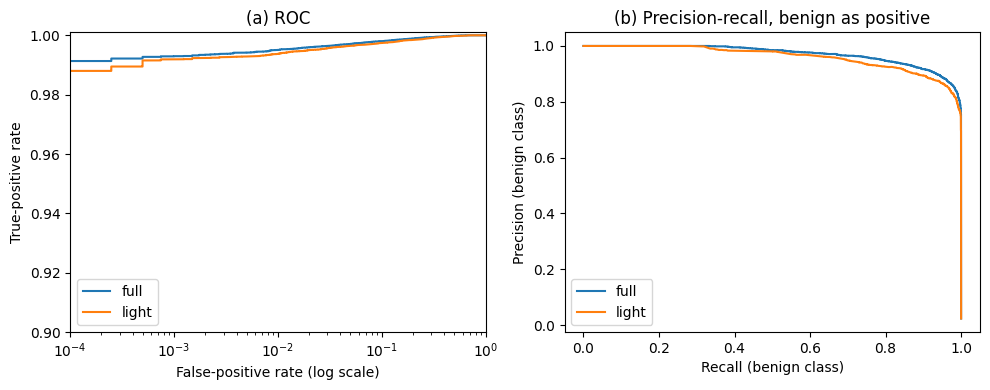

model  target_far  test_far  recall
 full      0.0005    0.0005  0.9924
 full      0.0010    0.0015  0.9930
 full      0.0050    0.0092  0.9950
 full      0.0100    0.0167  0.9957
 full      0.0200    0.0241  0.9962
light      0.0005    0.0005  0.9911
light      0.0010    0.0015  0.9922
light      0.0050    0.0110  0.9940
light      0.0100    0.0157  0.9946
light      0.0200    0.0241  0.9952
model metric   mean  ci_low  ci_high
 full    MCC 0.8869  0.8804   0.8936
 full    FPR 0.0027  0.0013   0.0045
 full recall 0.9937  0.9933   0.9941
light    MCC 0.8537  0.8468   0.8609
light    FPR 0.0005  0.0000   0.0012
light recall 0.9913  0.9908   0.9917
MCC difference full - light: mean 0.0332 95% CI [0.0301 0.0364]


In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
os.makedirs('/kaggle/working/figures', exist_ok=True)
yt, yv = y_te.values, y_val.values

S = {}
for name, m, cols in [('full', xgb_full, list(X_te.columns)), ('light', light_model, feats20)]:
    S[name] = dict(te=m.predict_proba(X_te[cols])[:, 1], va=m.predict_proba(X_val[cols])[:, 1])

# ---- ROC (log FPR axis) and PR (benign as the positive class) ----
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in S:
    f_, t_, _ = roc_curve(yt, S[name]['te']); ax[0].plot(f_, t_, label=name)
    p_, r_, _ = precision_recall_curve(1 - yt, 1 - S[name]['te']); ax[1].plot(r_, p_, label=name)
ax[0].set_xscale('log'); ax[0].set_xlim(1e-4, 1); ax[0].set_ylim(0.9, 1.001)
ax[0].set_xlabel('False-positive rate (log scale)'); ax[0].set_ylabel('True-positive rate'); ax[0].set_title('(a) ROC'); ax[0].legend()
ax[1].set_xlabel('Recall (benign class)'); ax[1].set_ylabel('Precision (benign class)'); ax[1].set_title('(b) Precision-recall, benign as positive'); ax[1].legend()
plt.tight_layout(); plt.savefig('/kaggle/working/figures/roc_pr.png', dpi=300, bbox_inches='tight'); plt.show()

# ---- Fixed-FAR: threshold chosen on VALIDATION benign flows, applied to test ----
rows = []
for name in S:
    vb = S[name]['va'][yv == 0]
    for tgt in [0.0005, 0.001, 0.005, 0.01, 0.02]:
        thr = np.quantile(vb, 1 - tgt)
        pr = S[name]['te'] >= thr
        tp = (pr & (yt == 1)).sum(); fn = ((~pr) & (yt == 1)).sum()
        fp = (pr & (yt == 0)).sum(); tn = ((~pr) & (yt == 0)).sum()
        rows.append(dict(model=name, target_far=tgt, test_far=round(fp/(fp+tn), 4), recall=round(tp/(tp+fn), 4)))
far = pd.DataFrame(rows); far.to_csv('/kaggle/working/results/fixed_far.csv', index=False)
print(far.to_string(index=False))

# ---- Bootstrap 95% CI on the test set (default threshold 0.5), 1000 resamples ----
rng = np.random.default_rng(0); n = len(yt); B = 1000
P = {k: (S[k]['te'] >= 0.5) for k in S}
def stats(pr, idx):
    y_, p_ = yt[idx], pr[idx]
    tp = float(((p_) & (y_ == 1)).sum()); tn = float(((~p_) & (y_ == 0)).sum())
    fp = float(((p_) & (y_ == 0)).sum()); fn = float(((~p_) & (y_ == 1)).sum())
    mcc = (tp*tn - fp*fn) / np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    return mcc, fp/(fp+tn), tp/(tp+fn)
res = {k: [] for k in P}
for b in range(B):
    idx = rng.integers(0, n, n)
    for k in P: res[k].append(stats(P[k], idx))
res = {k: np.array(v) for k, v in res.items()}
ci = []
for k in res:
    for j, mname in enumerate(['MCC', 'FPR', 'recall']):
        lo, hi = np.percentile(res[k][:, j], [2.5, 97.5])
        ci.append(dict(model=k, metric=mname, mean=round(res[k][:, j].mean(), 4), ci_low=round(lo, 4), ci_high=round(hi, 4)))
ci = pd.DataFrame(ci); ci.to_csv('/kaggle/working/results/bootstrap_ci.csv', index=False)
print(ci.to_string(index=False))
d = res['full'][:, 0] - res['light'][:, 0]
print("MCC difference full - light: mean", round(d.mean(), 4), "95% CI", np.round(np.percentile(d, [2.5, 97.5]), 4))

In [6]:
!cd /kaggle/working && rm -f backup2.zip && zip -rq backup2.zip results figures
import os; print(round(os.path.getsize('/kaggle/working/backup2.zip')/1e6, 2), "MB")
from IPython.display import FileLink
FileLink('/kaggle/working/backup2.zip')

0.14 MB


/kaggle/working/backup2.zip